<a href="https://colab.research.google.com/github/nieko1/Arctic-Hydrology-Assignment-/blob/main/Colab2_ThawDepthConnectivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab 2: Thaw depth and hydrological connectivity

In Colab 1, we estimated how precipitation and evapotranspiration influence the summer water balance of wet and dry polygon surfaces.

However, polygonal-tundra hydrology is not controlled by vertical fluxes alone.

During summer, the upper part of the permafrost thaws and forms the **active layer**. The depth of the thaw front determines how much unfrozen soil is available for:

- water storage;
- subsurface flow;
- hydrological connection between polygon centres, rims, troughs, and the catchment drainage network.

At Samoylov, the seasonal development of the frost table is therefore an important control on when stored water can begin to drain laterally.

In this notebook, we will:

1. estimate the seasonal development of thaw depth using a simplified **Stefan equation**;
2. compare thaw depth with the relative elevation of polygon rims and centres;
3. identify when lateral subsurface connectivity may become possible.

## Learning objective

By the end of this notebook, you should be able to explain how seasonal thaw can change the storage capacity and hydrological connectivity of polygonal tundra.

### ASSUMPTION

We represent thaw as a one-dimensional vertical process controlled primarily by accumulated positive air temperature.

This ignores several processes that can influence real thaw depth, including differences in soil moisture, vegetation, snow cover, soil thermal properties, and lateral heat transport.

## 1. Estimating seasonal thaw depth

We estimate thaw depth using a simplified Stefan-type model.

The model assumes that thaw progresses downward as positive air temperatures accumulate through the summer:

$$d(t)=\sqrt{\frac{2 K_h|J(t)|}{\rho_w L_{\mathrm{sl}} \theta_w}}$$


where:

- $d(t)$ = thaw depth [m]
- $K_h$ = soil thermal conductivity [W m$^{-1}$ K$^{-1}$]
- $J(t)$ = cumulative positive thawing-degree time [K s]
- $\rho_w$ = density of water [kg m$^{-3}$]
- $L_{sl}$ = latent heat of fusion of water [J kg$^{-1}$]
- $\theta_w$ = volumetric water fraction [-]

Soils with different proportions of water, mineral material, organic matter, and air have different thermal conductivities and therefore different rates of thaw.

For this exercise, soil thermal conductivity is approximated as:

$$
K_h
\approx
\left(
\theta_w k_w^{1/2}
+
\theta_m k_m^{1/2}
+
\theta_o k_o^{1/2}
+
\theta_a k_a^{1/2}
\right)^2
$$

where the $\theta$ terms are volumetric fractions of water, mineral material, organic matter, and air.

### ASSUMPTION

The model uses air temperature as the thermal forcing and represents the soil as a vertically uniform mixture with constant thermal properties.

It therefore does not explicitly represent layered peat and mineral soils, changing soil moisture, surface-energy balance, or lateral heat transport.

### Question

Which soil property in this model do you expect to have the strongest influence on thaw depth?

How would increasing the volumetric water content affect the amount of energy required to thaw the soil?

In [1]:
# ------------------------------------------------------------
# Soil thermal conductivity
# ------------------------------------------------------------

def thermal_conductivity(theta_w, theta_m, theta_o):
    """
    Estimate soil thermal conductivity [W m-1 K-1].

    theta_w : volumetric water fraction [-]
    theta_m : volumetric mineral fraction [-]
    theta_o : volumetric organic fraction [-]

    The remaining volume is assumed to be air.
    """

    # Thermal conductivities [W m-1 K-1]
    k_air = 0.025
    k_water = 0.57
    k_mineral = 3.8
    k_organic = 0.25

    theta_air = 1.0 - theta_w - theta_m - theta_o

    if theta_air < 0:
        raise ValueError(
            "Soil fractions must sum to 1 or less."
        )

    K_h = (
        theta_w * np.sqrt(k_water)
        + theta_m * np.sqrt(k_mineral)
        + theta_o * np.sqrt(k_organic)
        + theta_air * np.sqrt(k_air)
    ) ** 2

    return K_h


# ------------------------------------------------------------
# Stefan thaw-depth model
# ------------------------------------------------------------

def thaw_depth_stefan(
    temperature,
    theta_w,
    theta_m,
    theta_o
):
    """
    Calculate cumulative thaw depth [m]
    from daily mean air temperature.

    temperature : daily mean air temperature [°C]
    theta_w     : volumetric water fraction [-]
    theta_m     : volumetric mineral fraction [-]
    theta_o     : volumetric organic fraction [-]
    """

    # Physical constants
    rho_w = 1000.0      # water density [kg m-3]
    L_f = 334e3         # latent heat of fusion [J kg-1]
    dt = 86400.0        # seconds per day

    # Soil thermal conductivity
    K_h = thermal_conductivity(
        theta_w,
        theta_m,
        theta_o
    )

    # Only positive temperatures contribute to thaw
    positive_temperature = np.maximum(
        np.asarray(temperature, dtype=float),
        0.0
    )

    # Cumulative Stefan forcing
    J = np.cumsum(
        (K_h / theta_w)
        * positive_temperature
        * dt
    )

    # Thaw depth [m]
    thaw_depth = np.sqrt(
        2.0 * J
        / (rho_w * L_f)
    )

    return thaw_depth

In [ ]:
# ------------------------------------------------------------
# Load daily meteorological forcing
# ------------------------------------------------------------

from google.colab import files
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = next(iter(uploaded))
climate = pd.read_csv(io.BytesIO(uploaded[filename]))

# Identify the date column
date_candidates = [
    "date",
    "DateTime",
    "system:time_start",
    "time",
    "timestamp",
    "datetime",
]

date_column = next(
    (col for col in date_candidates if col in climate.columns),
    None
)

if date_column is None:
    raise ValueError("No date column found in the forcing data.")

climate[date_column] = pd.to_datetime(climate[date_column])

climate = (
    climate
    .sort_values(date_column)
    .set_index(date_column)
)

# Check that daily mean temperature is available
if "Tmean_C" not in climate.columns:
    raise ValueError(
        "Expected column 'Tmean_C' was not found."
    )

print(
    "Forcing period:",
    climate.index.min().date(),
    "to",
    climate.index.max().date()
)

print("Number of days:", len(climate))

display(
    climate[["Tmean_C"]].head()
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    climate.index,
    climate["Tmean_C"]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_ylabel("Mean air temperature [°C]")
ax.set_xlabel("Date")
ax.set_title("Daily mean air temperature")

plt.tight_layout()
plt.show()

## 2. Representing the soil

The Stefan model requires an estimate of the volumetric composition of the soil.

We describe the soil using four components:

- $\theta_w$ = water fraction
- $\theta_m$ = mineral fraction
- $\theta_o$ = organic fraction
- $\theta_a$ = air fraction

Together they must satisfy:

$$
\theta_w + \theta_m + \theta_o + \theta_a = 1
$$

For this simplified representation of a polygon rim, we use:

| Component | Volumetric fraction |
|---|---:|
| Water | 0.40 |
| Mineral material | 0.40 |
| Organic material | 0.10 |
| Air | 0.10 |

### ASSUMPTION

These fractions provide a simplified bulk representation of the thawing soil.

The water fraction is consistent with the approximately 41% volumetric water content observed in the thawed organic layer of a polygon rim at Samoylov. The mineral, organic, and air fractions are simplified model assumptions rather than measured site-specific bulk fractions.

In reality, the active layer is vertically heterogeneous, with an organic-rich surface layer overlying more mineral material.

In [ ]:
# ------------------------------------------------------------
# Define soil composition
# ------------------------------------------------------------

theta_w = 0.40   # water fraction [-]
theta_m = 0.40   # mineral fraction [-]
theta_o = 0.10   # organic fraction [-]

# Remaining pore space is assumed to contain air
theta_a = 1.0 - theta_w - theta_m - theta_o

print(f"Water fraction:   {theta_w:.2f}")
print(f"Mineral fraction: {theta_m:.2f}")
print(f"Organic fraction: {theta_o:.2f}")
print(f"Air fraction:     {theta_a:.2f}")

print(
    "Sum of fractions:",
    theta_w + theta_m + theta_o + theta_a
)


# ------------------------------------------------------------
# Calculate thermal conductivity
# ------------------------------------------------------------

K_h = thermal_conductivity(
    theta_w,
    theta_m,
    theta_o
)

print(
    f"\nEstimated thermal conductivity: "
    f"{K_h:.2f} W m-1 K-1"
)


# ------------------------------------------------------------
# Calculate thaw depth
# ------------------------------------------------------------

climate["thaw_depth_m"] = thaw_depth_stefan(
    temperature=climate["Tmean_C"],
    theta_w=theta_w,
    theta_m=theta_m,
    theta_o=theta_o
)


# ------------------------------------------------------------
# Plot seasonal thaw development
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    climate.index,
    climate["thaw_depth_m"]
)

ax.set_ylabel("Thaw depth [m]")
ax.set_xlabel("Date")
ax.set_title("Estimated seasonal thaw depth")

# Plot depth increasing downward
ax.invert_yaxis()

plt.tight_layout()
plt.show()


print(
    f"Maximum calculated thaw depth: "
    f"{climate['thaw_depth_m'].max():.2f} m"
)

## 3. Is the calculated thaw depth plausible?

The Stefan model is a simplified representation of seasonal thaw, so its output should be compared against observations before it is used to infer hydrological connectivity.

At Samoylov, field observations show that:

- surface thaw began near the end of May;
- thaw depth reached about 10 cm in early June;
- thaw depth reached about 15 cm by mid-June;
- the maximum active-layer thickness later in the season is typically on the order of 30–50 cm.

### Questions

1. Does the timing of thaw onset in your model agree approximately with the observations?

2. Is the calculated thaw depth in June of the same order of magnitude as the observed values?

3. What is the maximum thaw depth predicted by your model over the selected period?

4. If the model over- or underestimates thaw depth, which assumptions in the Stefan calculation could explain the mismatch?

Consider especially:

- using air temperature instead of surface or soil temperature;
- assuming constant soil thermal properties;
- representing the soil as one uniform layer;
- assuming constant water content.

## 4. From thaw depth to hydrological connectivity

Thaw depth is important not only because it determines the thickness of unfrozen soil, but also because it controls where water can flow.
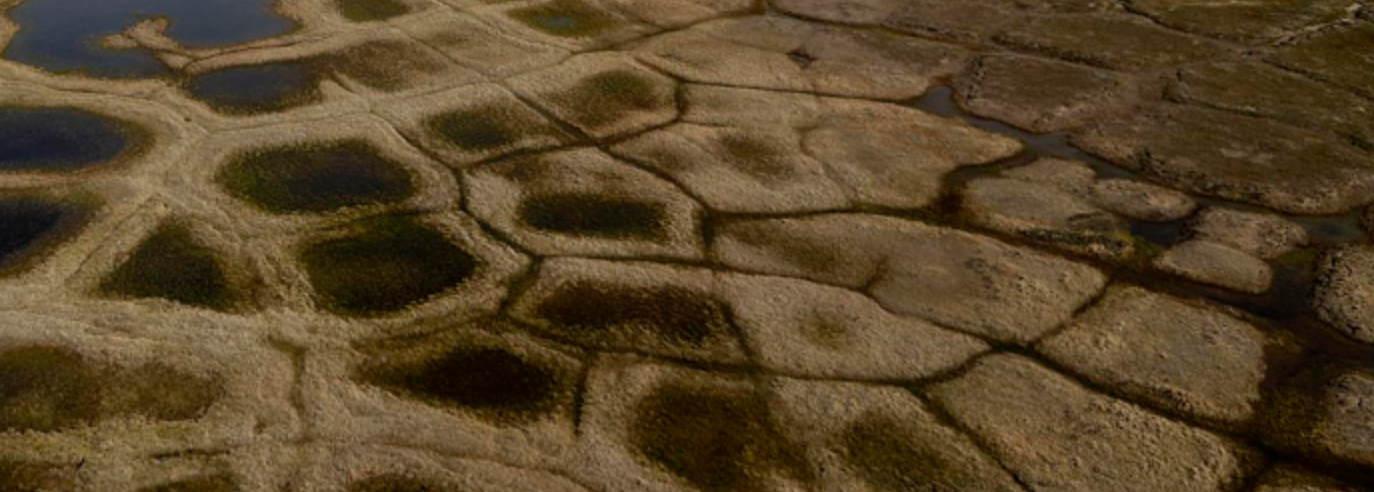
In low-centred polygonal tundra, wet polygon centres are surrounded by relatively elevated rims. Early in the summer, frozen soil within these rims can restrict subsurface drainage and allow water to remain stored in the polygon centres.

As the active layer deepens, previously frozen parts of the rim become available for subsurface flow. The hydrological role of the rim can therefore change through the summer:

$$
\text{shallow thaw}
\rightarrow
\text{restricted subsurface connectivity}
\\
\text{deeper thaw}
\rightarrow
\text{greater subsurface connectivity}
$$

Importantly, **thaw alone does not generate lateral flow**. Water must also be available, and there must be a hydraulic gradient connecting the polygon centre to neighbouring troughs or other drainage pathways.

### ASSUMPTION

We treat increasing thaw depth as an indicator of increasing **potential subsurface connectivity**.

This is a simplification. Actual lateral flow also depends on water-table position, soil hydraulic conductivity, polygon microtopography, and whether the rim is intact or degraded.

### Questions

1. Why can an intact polygon rim act as a hydrological barrier early in the summer?

2. Why would deeper thaw make subsurface drainage from the polygon centre more likely?

3. Would you expect polygons with degraded rims to respond in the same way? Explain why or why not.

## 5. When can a polygon centre become hydrologically connected through the rim?

We now translate thaw depth into a simple geometric indicator of hydrological connectivity.

Low-centred polygons contain depressed, wet centres surrounded by elevated rims. At Samoylov, rim heights commonly range from approximately 0.2 to 1.0 m above the polygon centres.

For this exercise, we represent a typical intact rim as:

$$
h_r = 0.50\ \mathrm{m}
$$

above the polygon-centre ground surface.

The elevation of the frost table beneath the rim can then be written relative to the polygon-centre surface as:

$$
z_f = h_r - d
$$

where:

- $h_r$ = rim height above the polygon centre [m]
- $d$ = thaw depth beneath the rim [m]
- $z_f$ = elevation of the frost table relative to the polygon-centre surface [m]

I the polygon-centre water table is close to or above the polygfon-centre ground surface, a simple condition for water to be able to flow through the rim is therefore:

$$
d \geq h_r
$$

where:

- $d$ = thaw depth beneath the polygon rim [m]
- $h_r$ = height of the polygon rim above the polygon-centre surface [m]

In this simplified case, the thaw depth beneath the rim must therefore be at least as large as the elevation difference between the rim and the polygon centre.

### ASSUMPTION

This is a **potential-connectivity threshold**, not a prediction of actual lateral flow.

We assume:

- a representative rim height of 0.50 m;
- the polygon-centre water table is close to the centre surface;
- thaw depth beneath the rim is spatially uniform;
- once the frost table drops below the centre level, an unfrozen subsurface pathway may exist.

Actual flow would additionally require a hydraulic gradient and sufficiently permeable soil.

### Question

1. Based on your thaw-depth curve, do you expect this 0.50 m threshold to be reached during the study period? Before calculating it, estimate approximately when you think this might occur.

In [ ]:
# ------------------------------------------------------------
# Potential subsurface connectivity through the rim
# ------------------------------------------------------------

rim_height_m = 0.50

climate["potential_connection"] = (
    climate["thaw_depth_m"] >= rim_height_m
)

connected_days = climate[
    climate["potential_connection"]
]

if len(connected_days) > 0:
    first_connection_date = connected_days.index[0]

    print(
        "Potential subsurface connection first becomes possible on:",
        first_connection_date.date()
    )

else:
    print(
        "The modelled thaw depth does not reach the "
        f"{rim_height_m:.2f} m rim-height threshold "
        "during the study period."
    )


# Plot thaw depth and connectivity threshold

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    climate.index,
    climate["thaw_depth_m"],
    linewidth=2,
    label="Modelled thaw depth"
)

ax.axhline(
    rim_height_m,
    linestyle="--",
    label="0.50 m rim-height threshold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Depth below rim surface [m]")
ax.set_title("Thaw depth and potential subsurface connectivity")

ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

## 6. Interpreting the connectivity estimate

The calculation above gives the date on which the modelled thaw depth first becomes equal to or greater than the assumed rim height.

This provides a simple estimate of when an unfrozen pathway beneath the rim may become geometrically possible.

However, the threshold should not be interpreted as the exact date on which lateral flow begins.

At Samoylov, hydrological connectivity changes progressively through the summer. Water can move through shallow organic layers above the frost table, while deeper subsurface pathways become available as thaw progresses.

### Questions

1. Does your model reach the 0.50 m connectivity threshold during the study period?

2. If so, when does this occur? If not, how close does the modelled thaw depth come to the threshold?

3. Observations at Samoylov show increasing subsurface drainage from intact polygons later in summer. Does the timing predicted by your simple threshold agree with this general pattern?

4. What could explain a mismatch between the calculated threshold and observed lateral flow?

Consider:

- variation in rim height between polygons;
- uncertainty in the calculated thaw depth;
- shallow flow above the frost table;
- differences in soil hydraulic conductivity;
- degraded or breached rims;
- changes in water-table elevation.

### ASSUMPTION

The 0.50 m threshold represents one idealized polygon geometry.

Real polygons differ substantially in rim height and morphology, so the onset of hydrological connectivity is unlikely to occur at the same time across the landscape.

## 7. From the annual water balance to runoff

So far, we have examined two parts of the hydrological system:

- precipitation and evapotranspiration determine how much water is available;
- seasonal thaw influences when and where that water can move laterally through the landscape.

We now combine these ideas using a simplified **annual catchment water balance**.

The annual water balance can be written as:

$$
P = ET + Q + \Delta S
$$

where:

- $P$ = annual precipitation [mm yr$^{-1}$]
- $ET$ = annual evapotranspiration [mm yr$^{-1}$]
- $Q$ = annual runoff [mm yr$^{-1}$]
- $\Delta S$ = annual change in catchment water storage [mm yr$^{-1}$]

At Samoylov, approximately half of the annual precipitation falls as snow and is released during snowmelt, so water storage changes strongly within the year.

Over a complete year, however, we make the simplifying assumption that the net change in catchment storage is small:

$$
\Delta S \approx 0
$$

so that:

$$
\boxed{Q \approx P-ET}
$$

This gives us a first-order estimate of the **amount of water available to leave the catchment over the year**.

### Important distinction

The annual water balance tells us approximately **how much** water may leave the catchment.

It does not tell us **when** that water leaves or **which flow paths** it follows.

Those questions depend on the seasonal development of the active layer and hydrological connectivity.

At Samoylov, increasing thaw depth during summer opens additional subsurface flow pathways and reduces storage thresholds, thereby changing the timing and routing of runoff.

We can therefore think of the catchment response as two linked controls:

$$
\boxed{P-ET}
\rightarrow
\text{water available for runoff}
$$

and

$$
\boxed{\text{thaw depth}}
\rightarrow
\text{seasonal hydrological connectivity}
$$

### Looking ahead: what happens under warming?

A warmer climate could affect both controls at the same time.

Higher temperatures may:

- increase evapotranspiration, changing the amount of water available for runoff;
- increase accumulated thawing-degree days, producing deeper or earlier thaw;
- therefore alter both the **magnitude** and the **timing** of catchment runoff.

In the next step, we will test this using a simple warming experiment by increasing air temperature while keeping the other forcing variables unchanged.

### ASSUMPTION

The annual runoff calculation assumes:

$$
\Delta S \approx 0
$$

over the complete year.

This does not imply that storage is unimportant. Large seasonal changes in snow, surface-water, soil-water, and active-layer storage can occur even if the net annual storage change is small.

### Questions

1. Why can $Q \approx P-ET$ be useful for estimating annual runoff but not for describing the timing of runoff during summer?

2. If climate warming increases both evapotranspiration and thaw depth, would you necessarily expect annual runoff to increase? Explain your reasoning.

## 8. How could polygon state affect annual runoff?

The surface classification from Colab 1 distinguishes relatively **wet** and **dry** parts of the polygonal landscape.

For the following sensitivity experiment, we interpret these classes as two contrasting hydrological states:

- **Wet surface** → LCP-like state
- **Dry surface** → HCP-like state

### ASSUMPTION

This is a simplified proxy.

The wet/dry classification is based on surface condition, not polygon morphology. In particular, dry surfaces can include elevated rims of low-centred polygons. The fractions calculated below should therefore not be interpreted as mapped HCP and LCP fractions.

Instead, we use them to explore how a shift from wetter, low-centred conditions toward drier, high-centred conditions could affect the annual water balance.

For each surface type, we estimate annual runoff as:

$$
Q_i = P - ET_i
$$

where $i$ represents either the wet or dry surface.

The contribution of each class to catchment-average runoff is then:

$$
Q_{i,\mathrm{contribution}} = f_i Q_i
$$

where $f_i$ is the fraction of the landscape occupied by that surface type.

The total catchment runoff estimate becomes:

$$
Q =
f_{\mathrm{wet}}Q_{\mathrm{wet}}
+
f_{\mathrm{dry}}Q_{\mathrm{dry}}
$$

This is a **water-balance decomposition**, not a physical attribution of runoff pathways. Water can be redistributed laterally between landscape units before reaching the catchment outlet.

In [ ]:
# ------------------------------------------------------------
# Annual runoff from wet and dry surface classes
# ------------------------------------------------------------

# Enter the wet and dry fractions calculated in Colab 1.
# They should sum to 1 because they are normalized over
# the wet + dry surface classes only.

wet_fraction = 0.80   # replace
dry_fraction = 0.20   # replace

# ------------------------------------------------------------
# Annual water-balance inputs
# ------------------------------------------------------------

annual_P = 323.0      # mm/year

# Annual ET estimates for the two surface types.
#
# ASSUMPTION:
# These values must come from the annual ET calculation.
# Do not replace them with the summer ET totals.

annual_ET_wet = xx.0   # mm/year -- replace with calculated value
annual_ET_dry = xx.0   # mm/year -- replace with calculated value


# ------------------------------------------------------------
# Runoff depth for each surface type
# ------------------------------------------------------------

Q_wet = annual_P - annual_ET_wet
Q_dry = annual_P - annual_ET_dry


# Area-weighted contribution of each class
Q_wet_contribution = wet_fraction * Q_wet
Q_dry_contribution = dry_fraction * Q_dry

Q_current = (
    Q_wet_contribution
    + Q_dry_contribution
)


# ------------------------------------------------------------
# Speculative polygon-degradation scenario
#
# Assume that part of the LCP-like wet surface changes
# toward an HCP-like dry state.
# ------------------------------------------------------------

conversion_fraction = 0.25

# 25% of the current LCP-like area is converted
# to the HCP-like state.

wet_fraction_future = (
    wet_fraction
    * (1 - conversion_fraction)
)

dry_fraction_future = (
    dry_fraction
    + wet_fraction * conversion_fraction
)


# Recalculate catchment runoff

Q_future = (
    wet_fraction_future * Q_wet
    + dry_fraction_future * Q_dry
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("CURRENT LANDSCAPE")
print(f"Wet / LCP-like fraction: {wet_fraction:.2f}")
print(f"Dry / HCP-like fraction: {dry_fraction:.2f}")
print(f"Wet-class runoff:        {Q_wet:.1f} mm/year")
print(f"Dry-class runoff:        {Q_dry:.1f} mm/year")
print(f"Catchment runoff:        {Q_current:.1f} mm/year")


print("\nSPECULATIVE DEGRADATION SCENARIO")
print(
    f"Fraction of LCP-like area converted: "
    f"{conversion_fraction:.0%}"
)

print(
    f"Wet / LCP-like fraction: "
    f"{wet_fraction_future:.2f}"
)

print(
    f"Dry / HCP-like fraction: "
    f"{dry_fraction_future:.2f}"
)

print(
    f"Catchment runoff: "
    f"{Q_future:.1f} mm/year"
)

print(
    f"Change in annual runoff: "
    f"{Q_future - Q_current:+.1f} mm/year"
)

## 9. Synthesis: how water availability and thaw interact

The annual water balance and the thaw calculation describe two different but connected controls on runoff.

The annual water balance estimates the total amount of water available to leave the catchment:

$$
P = ET + Q + \Delta S
$$

If the net change in catchment storage over the year is small,

$$
\Delta S \approx 0
$$

then:

$$
\boxed{Q \approx P-ET}
$$

This provides a first-order estimate of the **annual runoff volume**.

However, the water represented by $P-ET$ cannot necessarily leave the landscape immediately.

In polygonal tundra, water can be temporarily stored in polygon centres, ponds, troughs, and the active layer. Whether this stored water can move laterally depends partly on the development of the thawed layer.

At Samoylov, increasing thaw depth during summer opens additional subsurface flow pathways through polygon rims and reduces the effective isolation of polygon centres. This allows previously stored water to be redistributed toward troughs and eventually toward the catchment outlet.

We can therefore represent the hydrological system conceptually as:

$$
\boxed{
P-ET
\rightarrow
\text{water available for storage and runoff}
}
$$

while:

$$
\boxed{
\text{thaw depth + polygon morphology}
\rightarrow
\text{ability of stored water to move laterally}
}
$$

The annual runoff estimate therefore represents the **amount of water leaving the catchment over a long period**, whereas the thaw model helps explain **when and through which pathways that water can be released**.

### Implications for climate change

Climate warming could affect both parts of this system.

Higher temperatures may:

- alter evapotranspiration and therefore the annual amount of water available for runoff;
- increase active-layer thickness and cause subsurface pathways to become available earlier or at greater depth;
- promote changes in polygon morphology, which may further alter storage and connectivity.

### ASSUMPTION

We do not explicitly calculate lateral flow through the thawed soil.

Instead, the annual water balance estimates the long-term runoff magnitude, while the thaw calculation is used as an indicator of potential hydrological connectivity.

The model therefore separates **how much water is available to leave the catchment** from **how easily that water can move through the polygonal landscape**.

### From this simplified model to process-based hydrology

The calculations in this notebook deliberately simplify the hydrology of polygonal tundra.

Our annual water balance estimates the **total amount of water available for runoff**, while the thaw calculation indicates when subsurface connectivity may become possible. We do not explicitly simulate the redistribution of water between polygon centres, rims, troughs, and the catchment outlet.

More detailed studies have represented these processes explicitly.

At Samoylov, Helbig et al. showed that runoff production depends on the interaction between water storage, polygon microtopography, thaw depth, and lateral surface and subsurface flow. Increasing thaw depth during summer opens new flow pathways and alters the release of stored water through the thaw season.

Similarly, [Speetjens et al. (2024)](https://doi.org/10.1016/j.scitotenv.2024.170931) developed a coupled hydrological–DOC model for low-centred and high-centred ice-wedge polygons. Their simulations resolve how runoff and dissolved organic carbon export are distributed through the thaw season and how these fluxes may change as the active layer deepens, the thaw season lengthens, and polygon morphology shifts under a warmer climate.

These studies illustrate an important distinction:

$$
\text{annual water balance}
\rightarrow
\text{how much water is available}
$$

whereas

$$
\text{seasonal process models}
\rightarrow
\text{when, where, and through which pathways water and solutes are transported}
$$

This distinction is particularly important for substances such as dissolved organic carbon (DOC), because changes in flow-path depth, residence time, and connectivity can alter carbon export even when changes in annual runoff are relatively small.

### Looking ahead

In the next exercise, we move from process understanding at Samoylov to the pan-Arctic scale.

Rather than attempting to reproduce all of these detailed processes everywhere, we will ask:

> **Where do the environmental conditions exist that make Samoylov-like hydrological behaviour plausible?**

We will use the ARctic CAtchment DatabasE (ARCADE; [Speetjens et al., 2023](https://doi.org/10.5194/essd-15-541-2023)) to identify those environmental analogues and to examine where differences in climate, active-layer thickness, surface water, topography, and ice-wedge polygon coverage may cause the process model to behave differently.